In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
from astropy.io import fits
import camb
import math
from camb import model, initialpower
print('Using CAMB %s'%(camb.__version__))
plots_directory = "/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkySimulation/plots/"
data_directory = "/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkySimulation/data/"
os.chdir(data_directory)
print("Current working directory:", os.getcwd())

Using CAMB 1.5.9
Current working directory: /mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkySimulation/data


In [3]:
from SkySimulation import PK
freq = 1000
ks = np.linspace(0.001,0.8,1000)
pk1 = 2e-9*(ks/0.05)**(0.96-1)
#PK(k, As, ns, amp, freq, wid, centre, phase)
pk2 = PK(ks,2e-9, 0.96,0.0599,freq, 0.04, 0.06, 0)

## Load 

In [4]:
Tcmb = 2.7255
CF = (Tcmb*10**6)**2

#Converting the c_ls^TT to Dls
def Dls(l,CTT):
    Dl = [l[i]*(l[i]+1)*CTT[i]/(2*math.pi) for i in range(len(l))]
    return Dl

#Conerting Dls to the c_ls^TT
def Cls(l,DlTT):
    ClTT = [(2*math.pi)/(CF*l[i]*l[i]+1)*DlTT[i] for i in range(len(l))]
    return ClTT

In [5]:
def read_map(file_path):
    """
    Reads a Healpy map from a FITS file and flattens the data.
    Args:
        file_path (str): Path to the FITS file containing the Healpy map.
    Returns:
        np.ndarray: Flattened array of the map data.
    """

    with fits.open(file_path) as hdul:
        hdul.info()
        if len(hdul) > 1 and hasattr(hdul[1], 'columns'):
            print(hdul[1].columns)
        return np.concatenate(hdul[1].data['T'])

Filename: ./simulated_data/simulated_maps/cmb_map_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   


ColDefs(
    name = 'T'; format = '1024D'
)


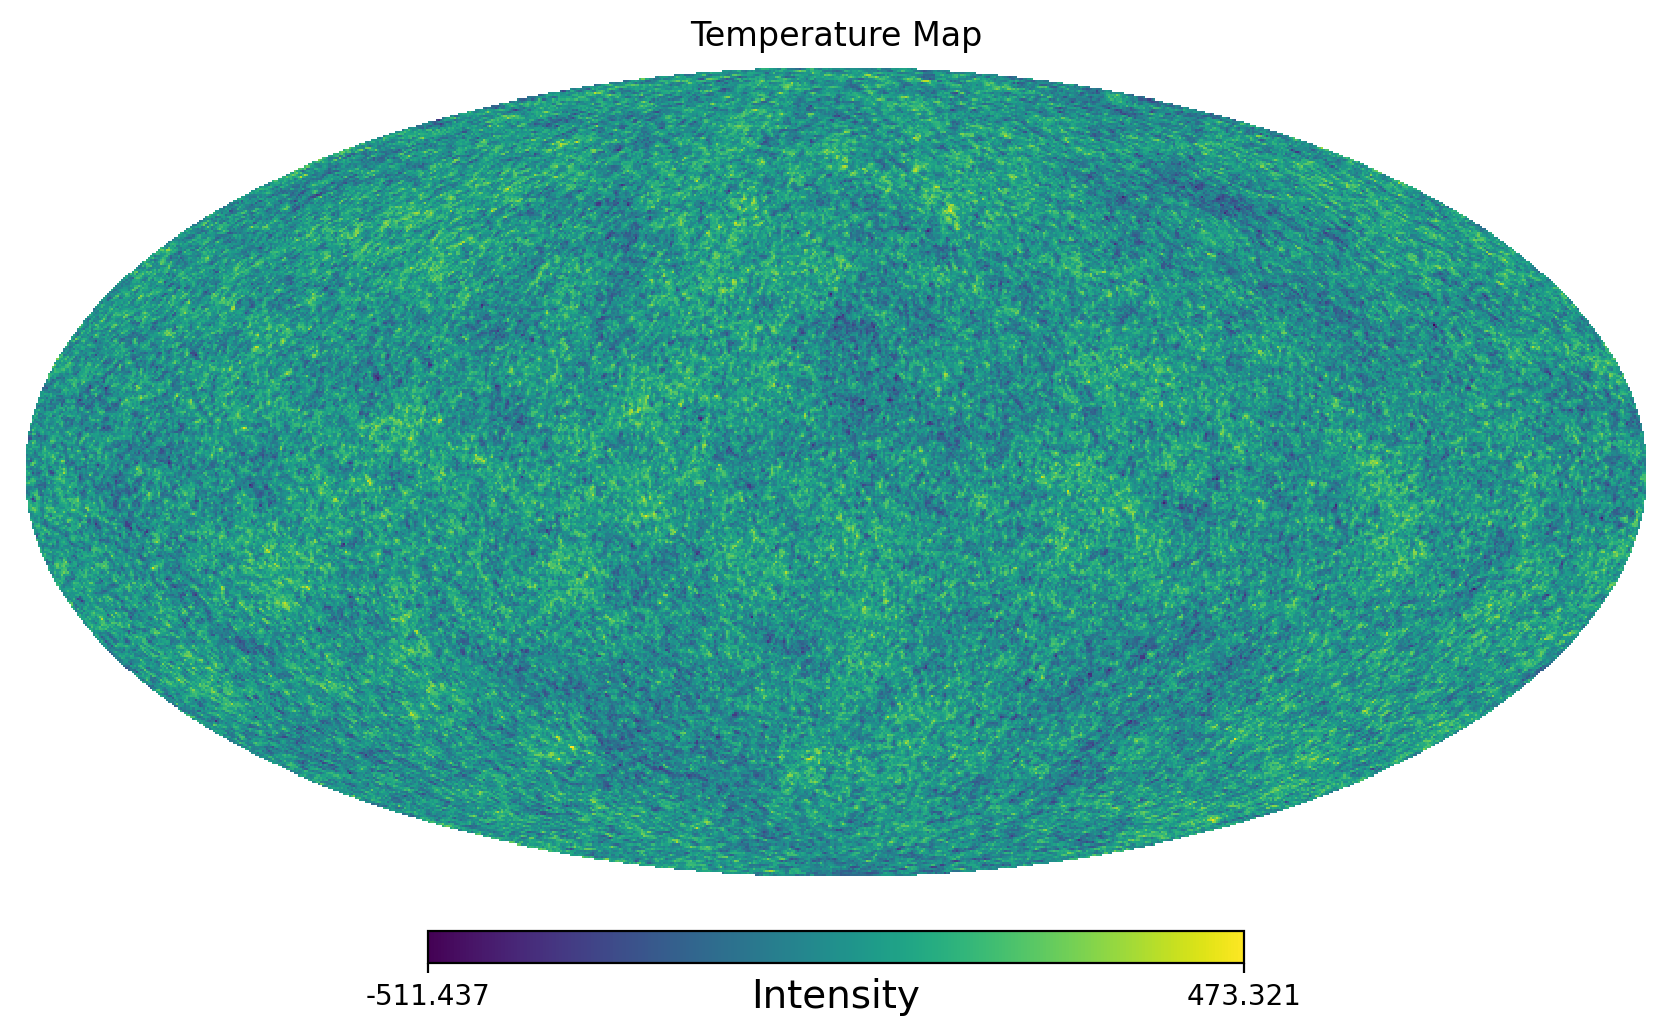

Filename: ./simulated_data/simulated_maps/cmb_map_feature_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)


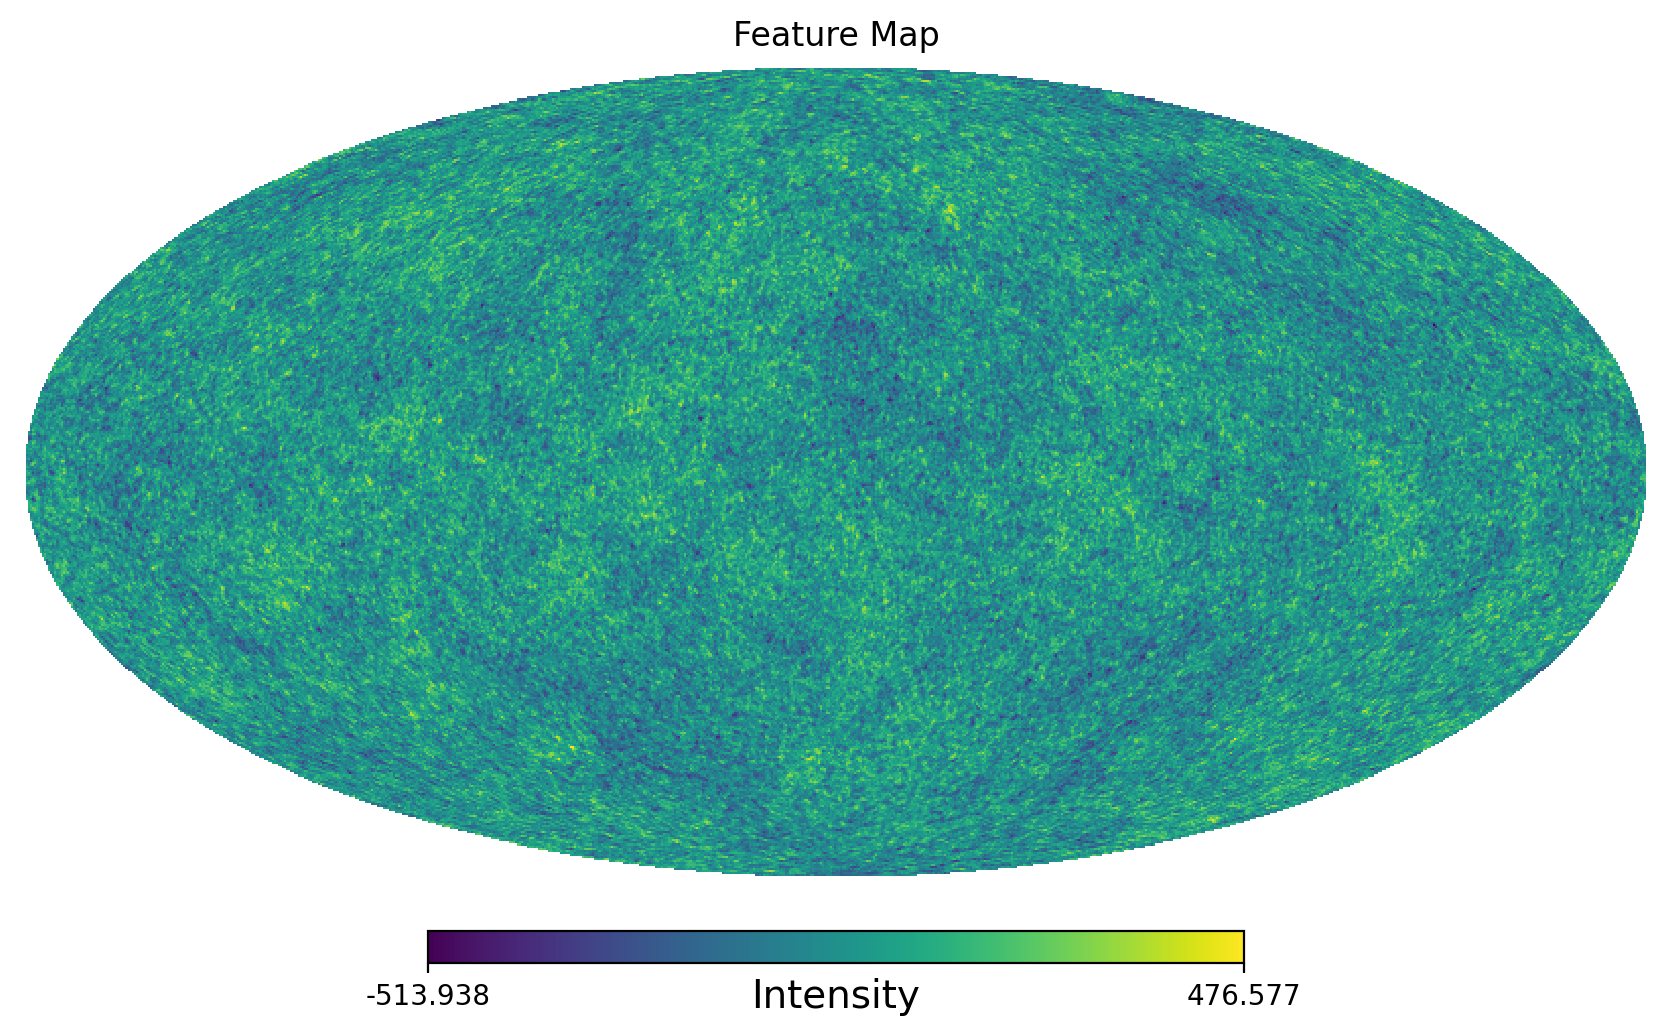

In [6]:
import healpy as hp
path_lcdm = "./simulated_data/simulated_maps/"
map_temp_data = read_map(path_lcdm + 'cmb_map_0.fits')
hp.mollview(map_temp_data, title="Temperature Map", unit="Intensity")
plt.show()
path_feature = "./simulated_data/simulated_maps/"
map_feature_data = read_map(path_feature + 'cmb_map_feature_0.fits')
hp.mollview(map_feature_data, title="Feature Map", unit="Intensity")
plt.show()

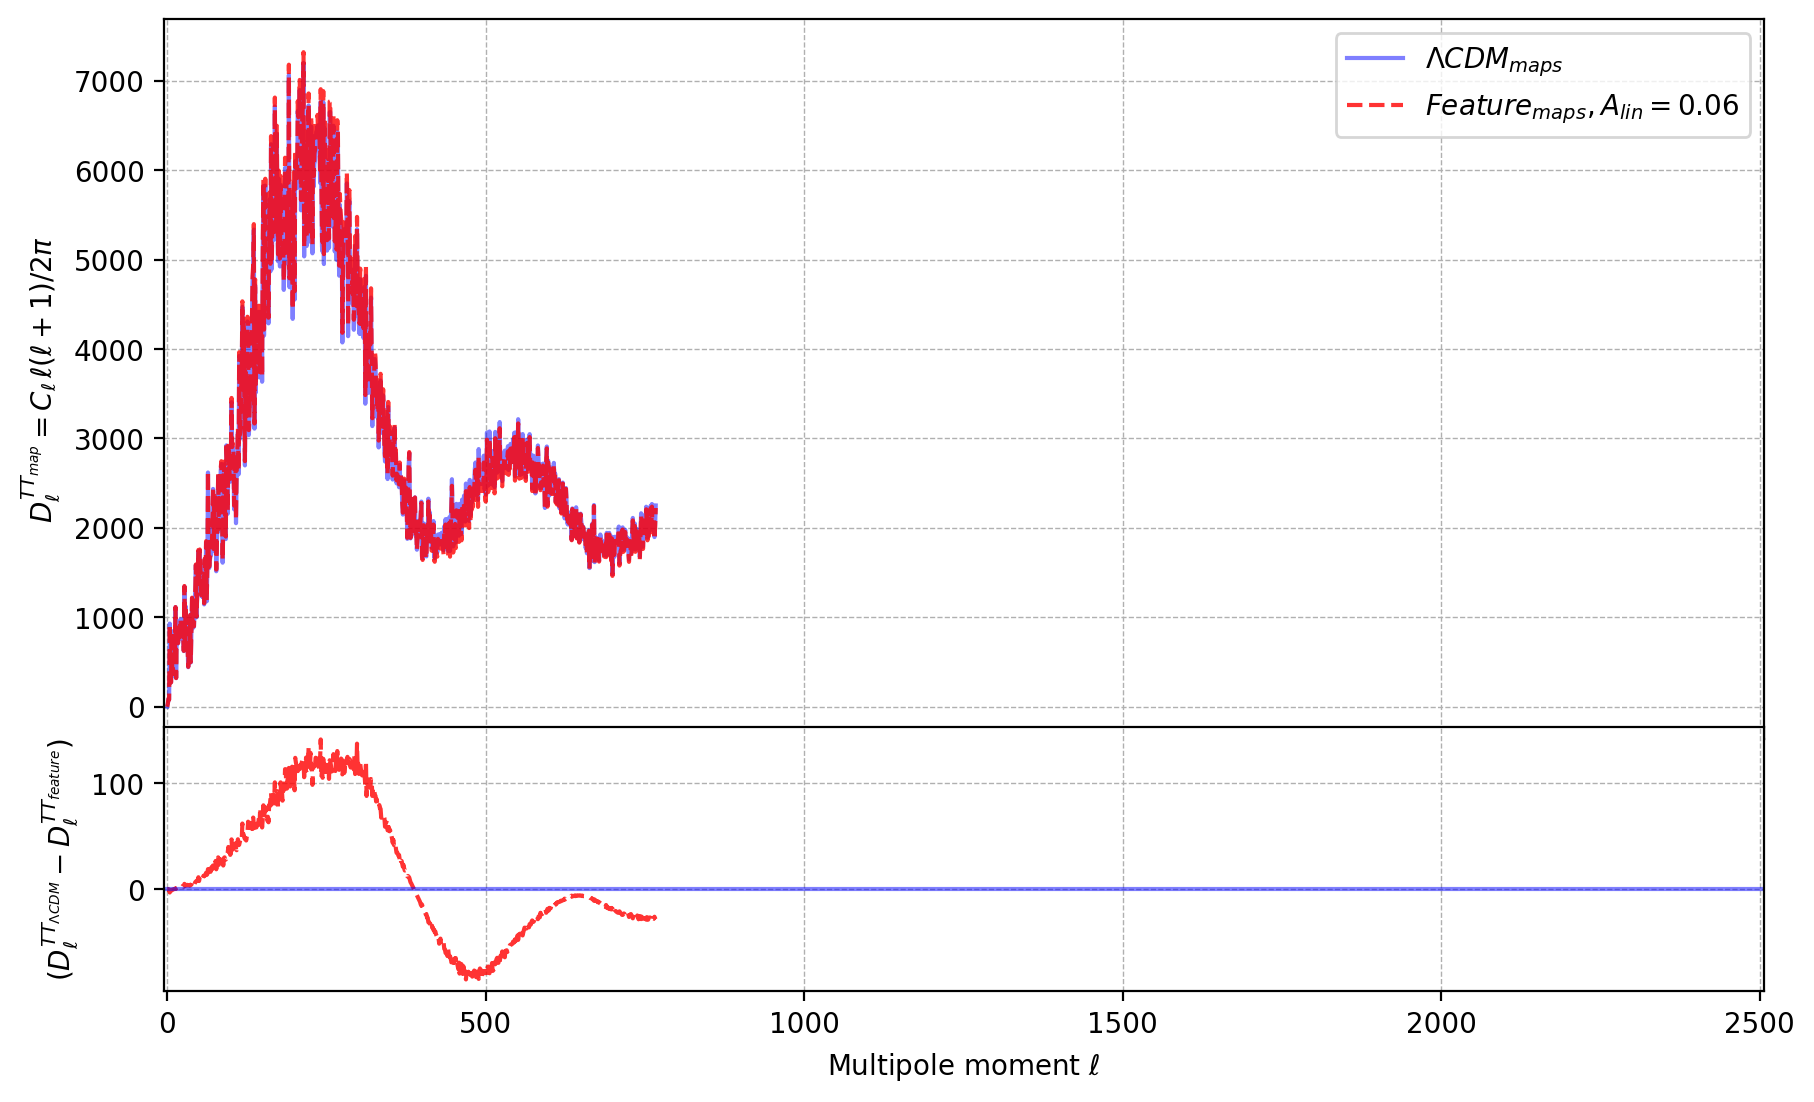

In [7]:
#Compute the power spectra
cl_tt_map_feature = hp.anafast(map_feature_data , pol=True)
cl_tt_map_lcdm = hp.anafast(map_temp_data , pol=True)

ell = np.arange(2507)
#lmax = len(cl_tt_map)
lmax = len(cl_tt_map_feature)

fig = plt.figure(figsize=(10, 6))

#Upper plot (Power Spectrum)
frame1 = fig.add_axes((.1, .4, .8, .6))
frame1.plot(ell[:lmax], Dls(ell[:lmax], cl_tt_map_lcdm)[:lmax], 
            label='$\Lambda CDM_{maps}$', alpha=0.5, color='blue')
frame1.plot(ell[:lmax], Dls(ell[:lmax], cl_tt_map_feature)[:lmax], 
            label='$Feature_{maps}, A_{lin}=0.06$', alpha=0.8, color='red', linestyle='--')
#frame1.plot(ell, Power_spectra_normal[1], 
            #label='$\Lambda CDM$', color='gray')
frame1.set_xlabel(r'Multipole moment $\ell$')
frame1.set_ylabel(r'$D_\ell^{TT_{map}}=C_\ell \, \ell(\ell+1)/2\pi$')
frame1.set_xlim(-5, 2507)
frame1.tick_params(axis='x', labelsize=0.1)
frame1.grid(True, which='both', linestyle='--', linewidth=0.5)
frame1.legend()
 
frame2 = fig.add_axes((.1, .19, .8, .22), sharex=frame1)
#diff1 = (Dls(ell[:lmax], cl_tt_map_feature) - Power_spectra_normal[1][:lmax])
#diff2 = (Dls(ell[:lmax], cl_tt_map_lcdm) - Power_spectra_normal[1][:lmax])
diff1 = np.array(Dls(ell[:lmax], cl_tt_map_feature)) - np.array(Dls(ell[:lmax], cl_tt_map_lcdm))
#frame2.plot(ell[:lmax], diff2, color='blue', alpha=0.5)
frame2.plot(ell[:lmax], diff1, alpha=0.8, color='red', linestyle='--')
frame2.axhline(y=0, alpha=0.5, color='blue')
frame2.set_xlabel(r'Multipole moment $\ell$')
frame2.set_ylabel(r'$(D_\ell^{TT_{\Lambda CDM}} - D_\ell^{TT_{feature}})$')
frame2.tick_params(axis='x', labelsize=10)
frame2.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()
#The plot looks that way, becuse we're taking the extreme values of the simulated data. In principle, the difference [-20,20]

In [8]:
path_feature = "./simulated_data/simulated_maps/"
map_feature_data = read_map(path_feature + './Ae1/cmb_map_feature_0.fits')

Filename: ./simulated_data/simulated_maps/./Ae1/cmb_map_feature_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)


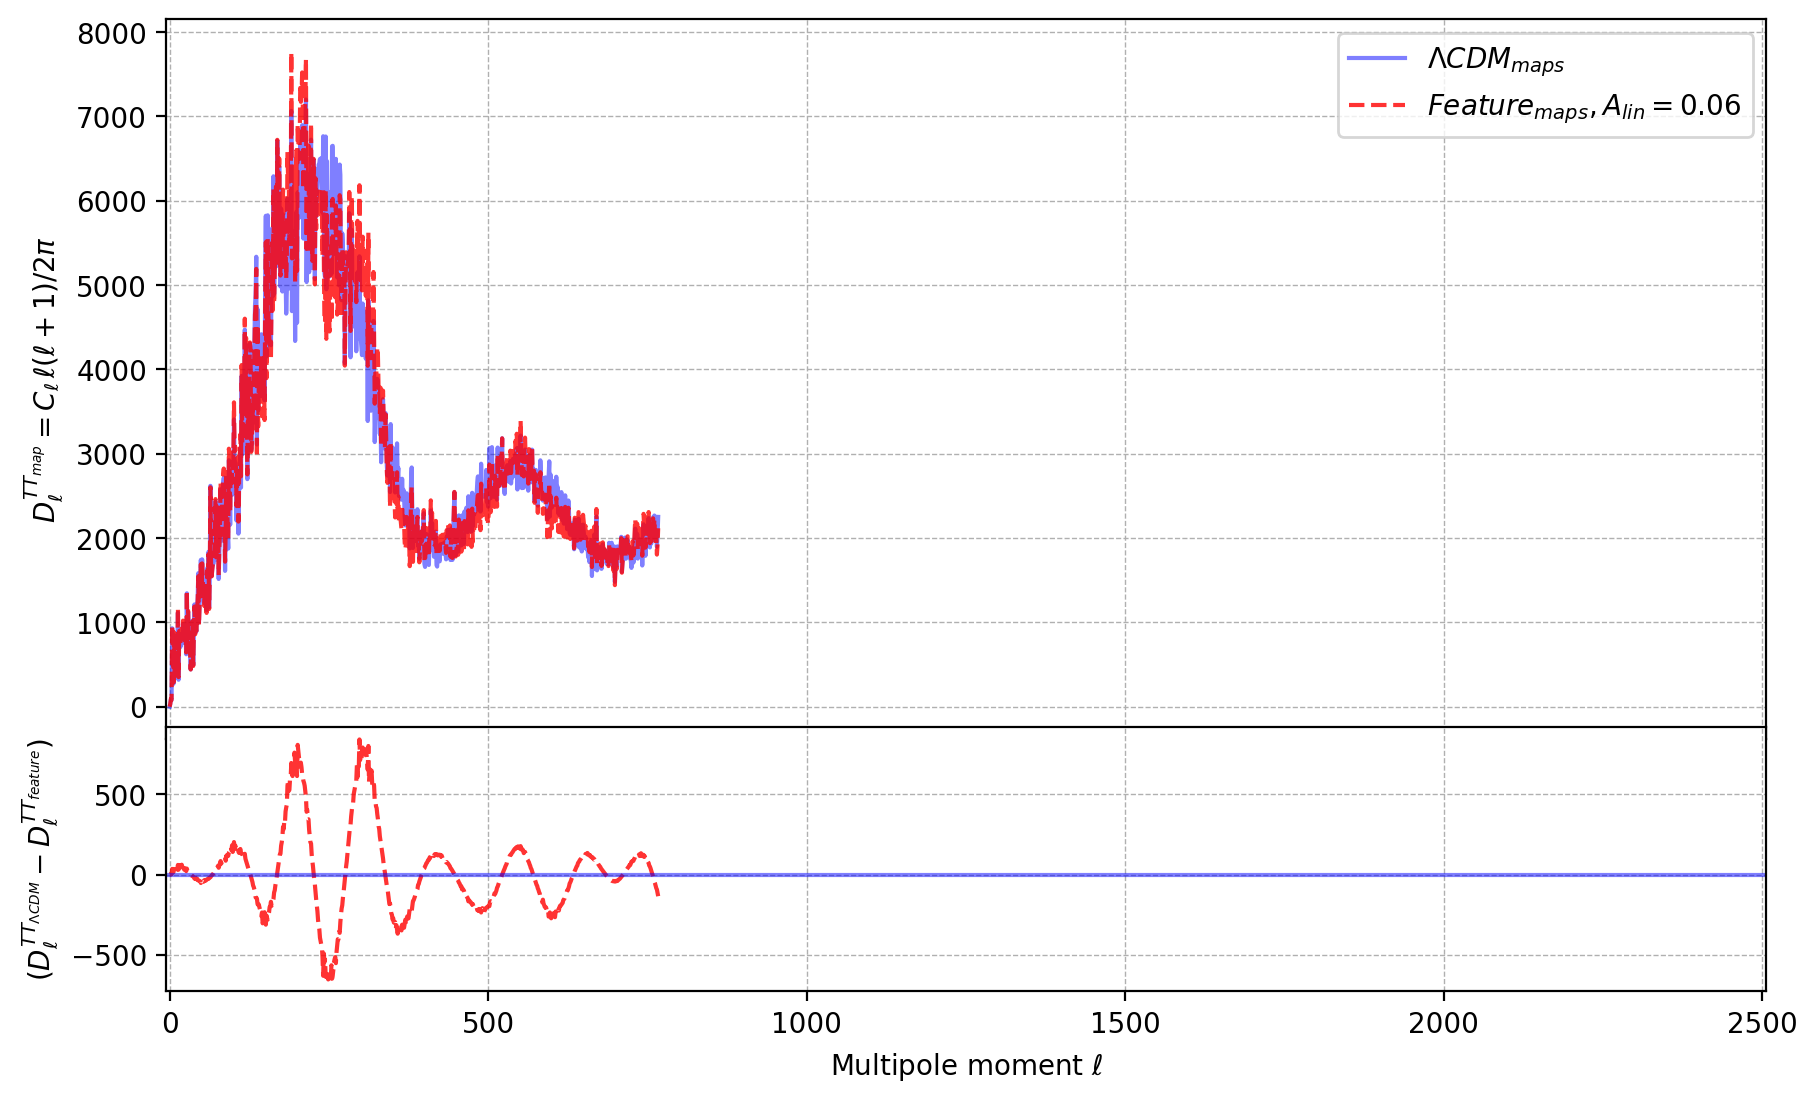

In [ ]:
#Compute the power spectra
cl_tt_map_feature = hp.anafast(map_feature_data , pol=True)
cl_tt_map_lcdm = hp.anafast(map_temp_data , pol=True)

ell = np.arange(2507)
#lmax = len(cl_tt_map)
lmax = len(cl_tt_map_feature)

fig = plt.figure(figsize=(10, 6))

#Upper plot (Power Spectrum)
frame1 = fig.add_axes((.1, .4, .8, .6))
frame1.plot(ell[:lmax], Dls(ell[:lmax], cl_tt_map_lcdm)[:lmax], 
            label='$\Lambda CDM_{maps}$', alpha=0.5, color='blue')
frame1.plot(ell[:lmax], Dls(ell[:lmax], cl_tt_map_feature)[:lmax], 
            label='$Feature_{maps}, A_{lin}=1$', alpha=0.8, color='red', linestyle='--')
#frame1.plot(ell, Power_spectra_normal[1], 
            #label='$\Lambda CDM$', color='gray')
frame1.set_xlabel(r'Multipole moment $\ell$')
frame1.set_ylabel(r'$D_\ell^{TT_{map}}=C_\ell \, \ell(\ell+1)/2\pi$')
frame1.set_xlim(-5, 2507)
frame1.tick_params(axis='x', labelsize=0.1)
frame1.grid(True, which='both', linestyle='--', linewidth=0.5)
frame1.legend()
 
frame2 = fig.add_axes((.1, .19, .8, .22), sharex=frame1)
#diff1 = (Dls(ell[:lmax], cl_tt_map_feature) - Power_spectra_normal[1][:lmax])
#diff2 = (Dls(ell[:lmax], cl_tt_map_lcdm) - Power_spectra_normal[1][:lmax])
diff1 = np.array(Dls(ell[:lmax], cl_tt_map_feature)) - np.array(Dls(ell[:lmax], cl_tt_map_lcdm))
#frame2.plot(ell[:lmax], diff2, color='blue', alpha=0.5)
frame2.plot(ell[:lmax], diff1, alpha=0.8, color='red', linestyle='--')
frame2.axhline(y=0, alpha=0.5, color='blue')
frame2.set_xlabel(r'Multipole moment $\ell$')
frame2.set_ylabel(r'$(D_\ell^{TT_{\Lambda CDM}} - D_\ell^{TT_{feature}})$')
frame2.tick_params(axis='x', labelsize=10)
frame2.grid(True, which='bothrb', linestyle='--', linewidth=0.5)

plt.show()